In [1]:
import os
os.chdir("/users/ffbence/dose")

In [2]:
dataPath = "data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training"
sample = "1ABB011"

In [3]:
!ls

aron_train.sh	 evaluation.py	shapes.json		 train_db.sh
cacheing.sh	 knowledge.md	start_notebook_aron.sh	 train_jzs.sh
checkpoints	 logs.log	start_notebook_pg.sh	 train.py
configs		 notebooks	start_notebook.sh	 utils
create_cache.py  README.md	start_notebook_zsofi.sh
data		 scripts	TODO.md


In [4]:
import torch
import torch.nn as nn
from omegaconf import OmegaConf

In [ ]:
from scripts.metrics import BeamMaskedMAELoss, IDDCurveLoss, Stratified_plan_level_MAE, GammaLoss
from monai.transforms import Compose,LoadImaged, EnsureChannelFirstd, ScaleIntensityRanged, Spacingd, ResizeWithPadOrCropd
from scripts.data_loader import ExtractSlabsAroundZ, InjectGaussianBeamPriord
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

In [ ]:
default_config = OmegaConf.load("configs/default_config.yaml")
db_config = OmegaConf.load("configs/db_config.yaml")

Physical point: [ 21.0454 -44.0176 -27.4164] Voxel coordinates: [155.9546 245.0176  43.8612] Z index: 44
 CT shape: torch.Size([392, 389, 106])


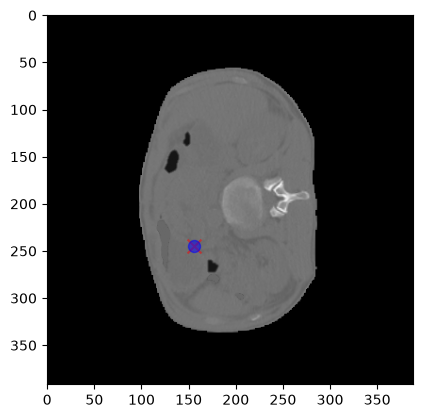

In [20]:
root = "data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training"
sample = "1ABB164"
sample_dict = { "ct": f"{root}/{sample}/image/ct.mha"}

transforms = Compose([
    LoadImaged(keys=["ct"], image_only=False),
])
ray = OmegaConf.load(f"{root}/{sample}/{sample}.json")
data = transforms(sample_dict)

affine = data['ct_meta_dict']['affine'].cpu().numpy()
inv_affine = np.linalg.inv(affine)
physical_iso_center = np.array(ray['iso_center'])[:3]
physical_target = np.array(ray['beams'][0]['rays'][0]['ray_target'])[:3]
physical_source = np.array(ray['beams'][0]['rays'][0]['ray_source'])[:3]
voxel_coords_iso_center = nib.affines.apply_affine(inv_affine, physical_iso_center)
voxel_coords_target = nib.affines.apply_affine(inv_affine, physical_target)
voxel_coords_source = nib.affines.apply_affine(inv_affine, physical_source)
z_index = int(np.round(voxel_coords_iso_center)[2])

print(f"Physical point: {physical_iso_center}", 
    f"Voxel coordinates: {    voxel_coords_iso_center}", 
      f"Z index: {z_index}\n",
      f"CT shape: {data['ct'].shape}" 
      )


plt.imshow(data['ct'][:, :, z_index], cmap='gray')
plt.scatter(voxel_coords_iso_center[0], voxel_coords_iso_center[1], color='red', marker='x', s=100, alpha=0.5)
plt.scatter(voxel_coords_target[0], voxel_coords_target[1], color='blue', marker='o', s=75, alpha=0.5)

# DATA LOADER TIMING

In [2]:

from scripts.data_loader import get_loaders
import tqdm
from omegaconf import OmegaConf
import time
cfg = OmegaConf.load(f"configs/default_config.yaml")
cfg = cfg['atlasz']
cfg['batch_size'] = 32
cfg['dataset_type'] = "persistent"
train_loader, val_loader = get_loaders(cfg = cfg, hw = "atlasz")


In [3]:
pbar = tqdm.tqdm(train_loader,total=10, desc="Loading training data")
t1 = time.time()
for i,batch in enumerate(pbar):
    if i >= 10:
        break
t2 = time.time()

Loading training data: 100%|██████████| 10/10 [00:07<00:00,  1.40it/s]


In [4]:
t1-t2

-7.153916835784912

In [5]:

from scripts.data_loader import get_loaders
import tqdm
from omegaconf import OmegaConf
import time
cfg = OmegaConf.load(f"configs/default_config.yaml")
cfg = cfg['atlasz']
cfg['batch_size'] = 32
cfg['dataset_type'] = "dataset"
train_loader, val_loader = get_loaders(cfg = cfg, hw = "atlasz")

In [6]:
pbar = tqdm.tqdm(train_loader,total=10, desc="Loading training data")
t1 = time.time()
for i,batch in enumerate(pbar):
    if i >= 10:
        break
t2 = time.time()

Loading training data:   0%|          | 0/10 [00:18<?, ?it/s]


KeyboardInterrupt: 

# config check

In [5]:
new_cfg = OmegaConf.merge(default_config, db_config)

In [6]:
default_config['komondor']['train']['adversarial']

{'use': False, 'adv_weight': 0.1, 'd_update_freq': 5}

In [7]:
new_cfg['komondor']

{'num_workers': 4, 'batch_size': 128, 'cache_dir': '/scratch/nr_dose', 'dataset_type': 'persistent', 'prefetch_factor': 2, 'persistent_workers': True, 'run_name': 'Modified_lr', 'modelname': 'DoTA', 'sigma': 4.0, 'dataset_list': 'data/dataset_list.json', 'train_list': 'data/train.json', 'val_list': 'data/val.json', 'margin_slices': 15, 'pixdim': [4.0, 4.0, 3.0], 'roi_size': [128, 128, 32], 'ct_min': -1024, 'ct_max': 2000, 'dotakwgs': {'in_channels': 2, 'out_channels': 1, 'channels': [32, 64, 128, 256], 'num_heads': 8, 'num_layers': 4}, 'unetkwgs': {'condition_dim': 3}, 'filmkwgs': {'condition_dim': 3}, 'attentionkwgs': {'condition_dim': 3}, 'losskwgs': {'masked_factor': 10.0, 'iid_curve_weight': 0.5, 'allMAE_weight': 0.5, 'total_variation_weight': 0.01}, 'train': {'num_epochs': 100, 'lr': 0.00028, 'use_warmups': False, 'fine_tune': False, 'adversarial': {'use': False, 'adv_weight': 0.1, 'd_update_freq': 5}}}

# Eda

In [6]:
def test_beam_masked_mae():
    torch.manual_seed(0)
    B, N, D, H, W = 2, 3, 16, 64, 64

    target = torch.rand(B, N, D, H, W)
    pred   = target + 0.05 * torch.randn(B, N, D, H, W)

    loss_fn = BeamMaskedMAELoss()
    loss    = loss_fn(pred, target)
    print(f"Loss (mean, 3D): {loss.item():.6f}")

    # reduction='none' → per-beam tensor
    per_beam = BeamMaskedMAELoss(reduction="none")(pred, target)
    print(f"Per-beam shape: {per_beam.shape}")   # (2, 3)
    print(f"Per-beam values:\n{per_beam}")

    # 2-D spatial (e.g. slice-wise)
    target_2d = torch.rand(B, N, H, W)
    pred_2d   = target_2d + 0.05 * torch.randn(B, N, H, W)
    loss_2d   = loss_fn(pred_2d, target_2d)
    print(f"Loss (mean, 2D): {loss_2d.item():.6f}")

    # Zero-dose beam edge case
    target_zero          = torch.rand(B, N, D, H, W)
    target_zero[:, 0, :] = 0.0   # first beam has zero gt dose
    pred_zero            = torch.rand(B, N, D, H, W)
    loss_zero            = loss_fn(pred_zero, target_zero)
    print(f"Loss with one zero-dose beam: {loss_zero.item():.6f}")

test_beam_masked_mae()

Loss (mean, 3D): 0.039881
Per-beam shape: torch.Size([2, 3])
Per-beam values:
tensor([[0.0400, 0.0398, 0.0399],
        [0.0399, 0.0397, 0.0399]])
Loss (mean, 2D): 0.039788
Loss with one zero-dose beam: 16665793.000000


In [7]:
def test_iid():
    import torch
 
    torch.manual_seed(42)
    B, N, H, W = 2, 3, 64, 64
 
    # ---- basic forward pass ----
    target = torch.rand(B, N, H, W)
    pred   = target + 0.05 * torch.randn(B, N, H, W)
 
    loss_fn = IDDCurveLoss(beam_dim=-1)           # depth = W axis
    loss    = loss_fn(pred, target)
    print(f"Loss (mean, beam_dim=-1): {loss.item():.6f}")
 
    loss_fn0 = IDDCurveLoss(beam_dim=0)           # depth = H axis
    loss0    = loss_fn0(pred, target)
    print(f"Loss (mean, beam_dim= 0): {loss0.item():.6f}")
 
    # ---- perfect prediction → loss should be ~0 ----
    loss_perfect = loss_fn(target, target)
    print(f"Loss (perfect pred):      {loss_perfect.item():.6f}")
 
    # ---- reduction='none' → per-beam ----
    per_beam = IDDCurveLoss(beam_dim=-1, reduction="none")(pred, target)
    print(f"Per-beam shape: {per_beam.shape}")    # (B, N) = (2, 3)
    print(f"Per-beam values:\n{per_beam}")
 
    # ---- single-channel total dose (B, H, W) ----
    target_2d = torch.rand(B, H, W)
    pred_2d   = target_2d + 0.05 * torch.randn(B, H, W)
    loss_2d   = IDDCurveLoss(beam_dim=-1)(pred_2d, target_2d)
    print(f"Loss (single-channel 2D): {loss_2d.item():.6f}")
 
    # ---- zero ground truth edge case ----
    target_z  = torch.zeros(B, N, H, W)
    pred_z    = torch.rand(B, N, H, W)
    loss_z    = loss_fn(pred_z, target_z)
    print(f"Loss (zero gt):           {loss_z.item():.6f}")   # should be large but finite

test_iid()

Loss (mean, beam_dim=-1): 0.010627
Loss (mean, beam_dim= 0): 0.011384
Loss (perfect pred):      0.000000
Per-beam shape: torch.Size([2, 3])
Per-beam values:
tensor([[0.0098, 0.0104, 0.0091],
        [0.0105, 0.0122, 0.0116]])
Loss (single-channel 2D): 0.010557
Loss (zero gt):           3219645184.000000


In [8]:
def test_local_gamma_3d():
    print("Running 3D Local Gamma Index Tests...")
    
    # Initialize evaluator with 1mm isotropic spacing
    evaluator = GammaLoss(voxel_spacing=(1.0, 1.0, 1.0))
    device = torch.device("cpu") # Can change to "cuda" if testing on GPU
    evaluator.to(device)

    # Base Ground Truth: A 5x5x5 volume with 100.0 dose everywhere
    # 1% dose tolerance = 1.0
    gt_base = torch.full((5, 5, 5), 100.0, device=device)

    # ---------------------------------------------------------
    # Test 1: Perfect Match
    # ---------------------------------------------------------
    pred_perfect = gt_base.clone()
    pass_rate = evaluator.local_gamma_3d(pred_perfect, gt_base).item()
    assert pass_rate == 1.0, f"Test 1 Failed: Perfect match should yield 1.0, got {pass_rate}"
    print("  [PASS] Test 1: Perfect Match")

    # ---------------------------------------------------------
    # Test 2: Borderline Dose Pass (+1.0%)
    # ---------------------------------------------------------
    # Every voxel has exactly +1% error (101.0). Spatial distance is 0mm.
    # Gamma = sqrt((0/1mm)^2 + (1.0/1.0)^2) = 1.0 -> PASS
    pred_borderline = gt_base + 1.0
    pass_rate = evaluator.local_gamma_3d(pred_borderline, gt_base).item()
    assert pass_rate == 1.0, f"Test 2 Failed: Borderline 1% difference should pass (1.0), got {pass_rate}"
    print("  [PASS] Test 2: Borderline Dose Pass (Exactly 1% diff)")

    # ---------------------------------------------------------
    # Test 3: Definite Dose Fail (+2.0%)
    # ---------------------------------------------------------
    # Every voxel has +2% error (102.0). 
    # Gamma = sqrt(0 + (2.0/1.0)^2) = 2.0 -> FAIL
    pred_fail = gt_base + 2.0
    pass_rate = evaluator.local_gamma_3d(pred_fail, gt_base).item()
    assert pass_rate == 0.0, f"Test 3 Failed: 2% difference should fail (0.0), got {pass_rate}"
    print("  [PASS] Test 3: Definite Dose Fail (>1% diff)")

    # ---------------------------------------------------------
    # Test 4: Pure Spatial Shift (Distance-to-Agreement)
    # ---------------------------------------------------------
    # Create a volume mostly 0, with a single "hot" voxel of 100.0
    gt_spatial = torch.zeros((5, 5, 5), device=device)
    gt_spatial[2, 2, 2] = 100.0 
    
    # Pred is shifted exactly 1 voxel (1.0 mm) along the X axis
    pred_spatial = torch.zeros((5, 5, 5), device=device)
    pred_spatial[2, 2, 3] = 100.0 
    
    # For the GT voxel at (2,2,2), the algorithm will search its 1mm neighborhood,
    # find the 100.0 at (2,2,3) in the shifted tensor math, and pass it.
    pass_rate = evaluator.local_gamma_3d(pred_spatial, gt_spatial).item()
    assert pass_rate == 1.0, f"Test 4 Failed: 1mm spatial shift should pass (1.0), got {pass_rate}"
    print("  [PASS] Test 4: Distance-to-Agreement (1mm Shift)")

    # ---------------------------------------------------------
    # Test 5: 10% Threshold Exclusion
    # ---------------------------------------------------------
    # Setup GT where one half is high dose (100.0), one half is low dose (5.0)
    # The maximum is 100.0, so the 10% threshold is 10.0.
    # Therefore, the 5.0 region should NOT be evaluated.
    gt_thresh = torch.zeros((4, 4, 4), device=device)
    gt_thresh[:, :, :2] = 100.0  # High dose region (Evaluated)
    gt_thresh[:, :, 2:] = 5.0    # Low dose region (Ignored)

    # We make the prediction PERFECT in the high dose region, 
    # but TERRIBLE in the low dose region (+10 dose error, which is 200% error locally).
    pred_thresh = gt_thresh.clone()
    pred_thresh[:, :, 2:] += 10.0 

    # Because the terrible predictions are below the 10% threshold, they should be ignored.
    # The pass rate should still be 100% (1.0).
    pass_rate = evaluator.local_gamma_3d(pred_thresh, gt_thresh).item()
    assert pass_rate == 1.0, f"Test 5 Failed: Errors below 10% threshold should be ignored, got {pass_rate}"
    print("  [PASS] Test 5: 10% Dose Threshold Exclusion")

    print("\nAll 3D Local Gamma Tests Passed Successfully! ✅")

test_local_gamma_3d()

Running 3D Local Gamma Index Tests...
  [PASS] Test 1: Perfect Match
  [PASS] Test 2: Borderline Dose Pass (Exactly 1% diff)
  [PASS] Test 3: Definite Dose Fail (>1% diff)
  [PASS] Test 4: Distance-to-Agreement (1mm Shift)
  [PASS] Test 5: 10% Dose Threshold Exclusion

All 3D Local Gamma Tests Passed Successfully! ✅


# Data Loader help

In [3]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ResizeWithPadOrCropd,
    EnsureTyped,
    ScaleIntensityRanged)

import torch
from omegaconf import OmegaConf
import os


In [4]:
## Load single sample

In [17]:
transforms = Compose([
    LoadImaged(keys=["HU"], image_only=False),
])

sample_dict = {"HU": f"{dataPath}/{sample}/image/ct.mha"}
data = transforms(sample_dict)
img,metadata = data["HU"], data["HU_meta_dict"]

In [35]:

sample = "1THB143"
transforms = Compose([
    LoadImaged(keys=["dose"], image_only=True),
])
sample_dict = {"dose": f"{dataPath}/{sample}/dose/Dose_B11_R9_L0.mha"}
data = transforms(sample_dict)


In [36]:
data['dose'].max()

metatensor(0.0015)

## Json Creation

In [38]:
import json
from monai.transforms import MapTransform, Compose, LoadImaged, EnsureChannelFirstd, Spacingd, CenterSpatialCropd
import nibabel as nib
import numpy as np
from monai.data import Dataset, DataLoader

In [39]:
def create_doserad_dataset(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    dataset_list = []
    base_dir = os.path.dirname(json_path)
    ct_path = os.path.join(base_dir, "image", "ct.mha")
    
    for beam in data.get('beams', []):
        beam_idx = beam['beam_idx']
        
        for ray in beam.get('rays', []):
            ray_idx = ray['ray_idx']
            ray_source = ray['ray_source'] # Expected format: [x, y, z] in mm
            
            for beamlet in ray.get('beamlets', []):
                beamlet_idx = beamlet['beamlet_idx']
                energy = beamlet['energy']
                
                # Reconstruct the specific dose filename
                dose_filename = f"Dose_B{beam_idx}_R{ray_idx}_L{beamlet_idx}.mha"
                dose_path = os.path.join(base_dir, "dose", dose_filename)
                
                if os.path.exists(dose_path) and os.path.exists(ct_path):
                    dataset_list.append({
                        "ct": ct_path,
                        "gt_dose": dose_path,
                        "ray_source_phys": ray_source,
                        "energy": energy
                    })
                    
    return dataset_list

In [107]:
jsonPaths[0].split("/")[-2]

'1ABB041'

In [108]:
import random
from collections import defaultdict

def create_split_datasets(json_paths, val_split=0.1):

    # 1. Group data by patient/sample
    patient_data = defaultdict(list)
    sample_names = [json_path.split("/")[-2] for json_path in json_paths]
    
    for i, json_path in enumerate(json_paths):        
        # Use your parser function (from earlier) for this specific sample
        sample_dicts = create_doserad_dataset(json_path)
        patient_data[sample_names[i]].extend(sample_dicts)
        
    # 2. Shuffle the patients, NOT the individual beamlets
    random.seed(42) # Exact reproducibility
    random.shuffle(sample_names)
    
    # 3. Calculate split index based on the number of patients
    split_idx = int(len(sample_names) * (1 - val_split))
    train_patients = sample_names[:split_idx]
    val_patients = sample_names[split_idx:]
    
    # 4. Flatten back into MONAI-ready lists
    train_list = []
    for p in train_patients:
        train_list.extend(patient_data[p])
        
    val_list = []
    for p in val_patients:
        val_list.extend(patient_data[p])
        
    print(f"Training Samples: {len(train_list)} (from {len(train_patients)} patients)")
    print(f"Validation Samples: {len(val_list)} (from {len(val_patients)} patients)")
    
    return train_list, val_list

In [40]:
dataset_list = create_doserad_dataset("/users/ffbence/dose/data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/1ABB006/1ABB006.json")

In [102]:
import glob
jsonPaths = glob.glob('data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/*/*.json')

In [113]:
train_list, val_list = create_split_datasets(jsonPaths)

Training Samples: 72360 (from 67 patients)
Validation Samples: 8639 (from 8 patients)


In [116]:
train_list = [
    {
        "ct": item["ct"],
        "gt_dose": item["gt_dose"],
        "condition": np.asarray([*item["ray_source_phys"], item["energy"]],dtype=np.float32).tolist(),
    }
    for item in train_list
]

val_list = [
    {
        "ct": item["ct"],
        "gt_dose": item["gt_dose"],
        "condition": np.asarray([*item["ray_source_phys"], item["energy"]],dtype=np.float32).tolist(),
    }
    for item in val_list
]

In [121]:
json.dump(train_list, open("data/train.json", "w"), indent=4)
json.dump(val_list, open("data/val.json", "w"), indent=4)

In [94]:
dataset_list = [create_doserad_dataset(json_path) for json_path in jsonPaths]
dataset_list = [item for sublist in dataset_list for item in sublist]  # Flatten the list of lists

In [98]:
dataset_list = [
    {
        "ct": item["ct"],
        "gt_dose": item["gt_dose"],
        "condition": np.asarray([*item["ray_source_phys"], item["energy"]],dtype=np.float32).tolist(),
    }
    for item in dataset_list
]

In [99]:
dataset_list[0]

{'ct': 'data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/1ABB041/image/ct.mha',
 'gt_dose': 'data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/1ABB041/dose/Dose_B0_R0_L0.mha',
 'condition': [-51.56999969482422,
  -1037.4300537109375,
  17.350000381469727,
  164.4532012939453]}

In [100]:
json.dump(dataset_list, open("dataset_list.json", "w"), indent=4)

In [41]:
class ExtractSlabAroundZ(MapTransform):
    def __init__(self, keys, source_key="ray_source_phys", margin_slices=10, allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)
        self.source_key = source_key
        self.margin_slices = margin_slices

    def __call__(self, data):
        d = dict(data)
        ray_source_phys = d[self.source_key] # [x, y, z]
        
        for key in self.key_iterator(d):
            img = d[key]
            
            # Extract the 4x4 affine matrix from the MONAI MetaTensor
            affine = img.affine.cpu().numpy()
            
            # Invert the affine to map physical coordinates back to voxel coordinates
            inv_affine = np.linalg.inv(affine)
            voxel_coords = nib.affines.apply_affine(inv_affine, ray_source_phys)
            
            # Assuming standard spatial arrangement where Z is the 3rd spatial dimension (idx 2)
            # Shape is [C, H, W, Z] after EnsureChannelFirstd
            z_voxel = int(np.round(voxel_coords[2]))
            
            z_min = max(0, z_voxel - self.margin_slices)
            z_max = min(img.shape[3], z_voxel + self.margin_slices + 1)
            
            # Slice the tensor. MONAI MetaTensors automatically update their affine 
            # metadata under the hood when sliced like this.
            d[key] = img[:, :, :, z_min:z_max]
            
        return d

In [42]:
train_transforms = Compose([
    LoadImaged(keys=["ct", "gt_dose"]),
    EnsureChannelFirstd(keys=["ct", "gt_dose"]),
    # Extract +/- 10 slices based on the physical ray location
    ExtractSlabAroundZ(keys=["ct", "gt_dose"], source_key="ray_source_phys", margin_slices=10),
    # Resample the extracted slabs to a fixed 1x1x1 mm resolution
    Spacingd(keys=["ct", "gt_dose"], pixdim=(1.0, 1.0, 1.0), mode="trilinear"),
    CenterSpatialCropd(keys=["ct", "gt_dose"], roi_size=(256, 256, 40))
])

In [49]:
sample_ds = Dataset(data=dataset_list, transform=train_transforms)
train_loader = DataLoader(sample_ds,batch_size=4,shuffle=True, num_workers=0)

In [57]:
len(dataset_list)

1080

In [58]:

for i, batch in enumerate(train_loader):
    print(f"CT shape: {batch['ct'].shape}")
    print(f"GT Dose shape: {batch['gt_dose'].shape}")
    print(f"Energies: {batch['energy']}")
    break

CT shape: torch.Size([4, 1, 256, 256, 40])
GT Dose shape: torch.Size([4, 1, 256, 256, 40])
Energies: tensor([131.5856, 164.4532, 106.3045, 161.4017], dtype=torch.float64)


In [61]:
batch = next(iter(train_loader))

In [62]:
ct = batch['ct']
gt = batch['gt_dose']

In [63]:
from monai.visualize import matshow3d

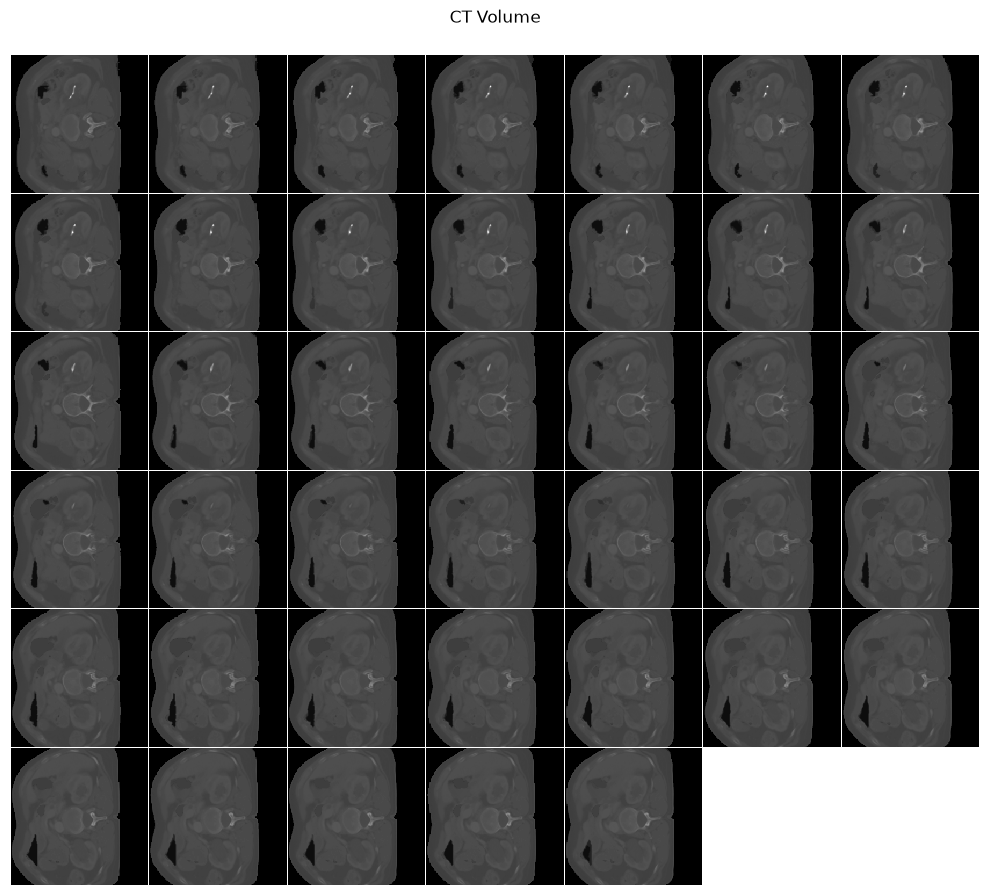

(<Figure size 1000x1000 with 1 Axes>,
 array([[   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan, -1024., -1024., ..., -1024., -1024.,    nan],
        [   nan, -1024., -1024., ..., -1024., -1024.,    nan],
        ...,
        [   nan, -1024., -1024., ...,    nan,    nan,    nan],
        [   nan, -1024., -1024., ...,    nan,    nan,    nan],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan]],
       shape=(1548, 1806), dtype=float32))

In [65]:
matshow3d(ct[0, 0], title="CT Volume", frame_dim=2, show=True,cmap='gray')

In [74]:
gt[0,0]

metatensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 

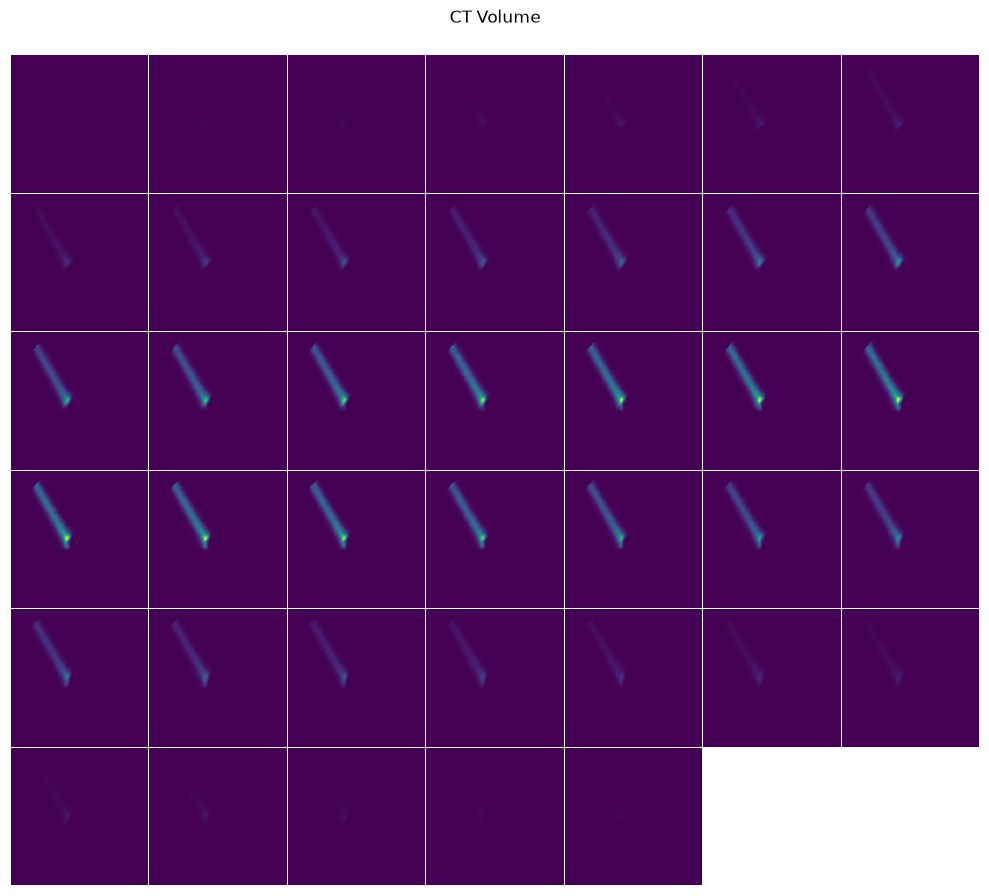

(<Figure size 1000x1000 with 1 Axes>,
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        ...,
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(1548, 1806), dtype=float32))

In [77]:
matshow3d(gt[3, 0], title="CT Volume", frame_dim=2, show=True)

# Data Loader

In [5]:
import json
import torch
import torch.nn as nn
from omegaconf import OmegaConf

In [6]:
cfg = OmegaConf.load(f"configs/default_config.yaml")
data_cfg = cfg['data']
hw_cfg = OmegaConf.load(f"configs/hw_config.yaml")

train_list = json.load(open(data_cfg['train_list'], "r"))
val_list = json.load(open(data_cfg['val_list'], "r"))

In [7]:
#old_base = "data/LMUK-RADONC-PHYS-RES__DoseRAD2026"
#new_base = hw_cfg['atlasz']['cache_dir']

#for item in train_list + val_list:
#    item['ct'] = item['ct'].replace(old_base, new_base)
#    item['gt_dose'] = item['gt_dose'].replace(old_base, new_base)
#json.dump(train_list, open("data/train.json", "w"), indent=4)
#json.dump(val_list, open("data/val.json", "w"), indent=4)

In [8]:
from scripts.data_loader import get_loaders

In [9]:
train_loader, val_loader = get_loaders(hw = "atlasz")

In [10]:
batch = next(iter(train_loader))

KeyboardInterrupt: 

In [10]:
batch['ct'].shape

torch.Size([64, 1, 256, 256, 64])

In [11]:
batch['condition'].shape

torch.Size([64, 4])

In [12]:
batch['condition'][0]

metatensor([-968.8400, -410.9800,   40.2100,  138.6352])

# Test slabbing

In [278]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn
from monai.transforms import LoadImaged, Compose
import json
from omegaconf import OmegaConf

from monai.visualize import matshow3d

In [267]:
dataPath = "/users/ffbence/dose/data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training"
sample = "1ABB011" 

In [271]:
transforms = Compose([
    LoadImaged(keys=["dose"], image_only=False),
])
B = 0
R = 0
L = 0
sample_dict = {"dose": f"{dataPath}/{sample}/dose/Dose_B{B}_R{R}_L{L}.mha"}
data = transforms(sample_dict)
img,metadata = data["dose"], data["dose_meta_dict"]

In [273]:
-58.3//3

-20.0

In [291]:
affine = img.affine.cpu().numpy()
inv_affine = np.linalg.inv(affine)

In [ ]:
physical_point = np.array(ray_source_phys)

# 2. Get the affine matrix from your loaded CT or Dose image
affine = img.affine.cpu().numpy()

# 3. Invert the affine to create a "Physical to Voxel" mapping
inv_affine = np.linalg.inv(affine)

# 4. Apply the inverted affine to your physical point
voxel_coords = nib.affines.apply_affine(inv_affine, physical_point)


# 5. The result is a continuous floating-point index. Round it to find the slice!
z_index = np.round(voxel_coords).astype(int)[-1]

In [304]:
z_index

np.int64(28)

In [302]:
torch.max(img[:,:,30])

metatensor(0.0007)

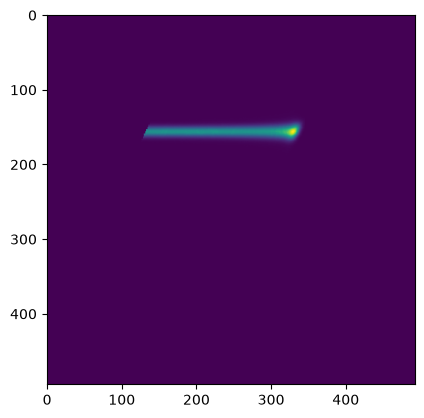

In [296]:
plt.imshow(img[:,:,28])

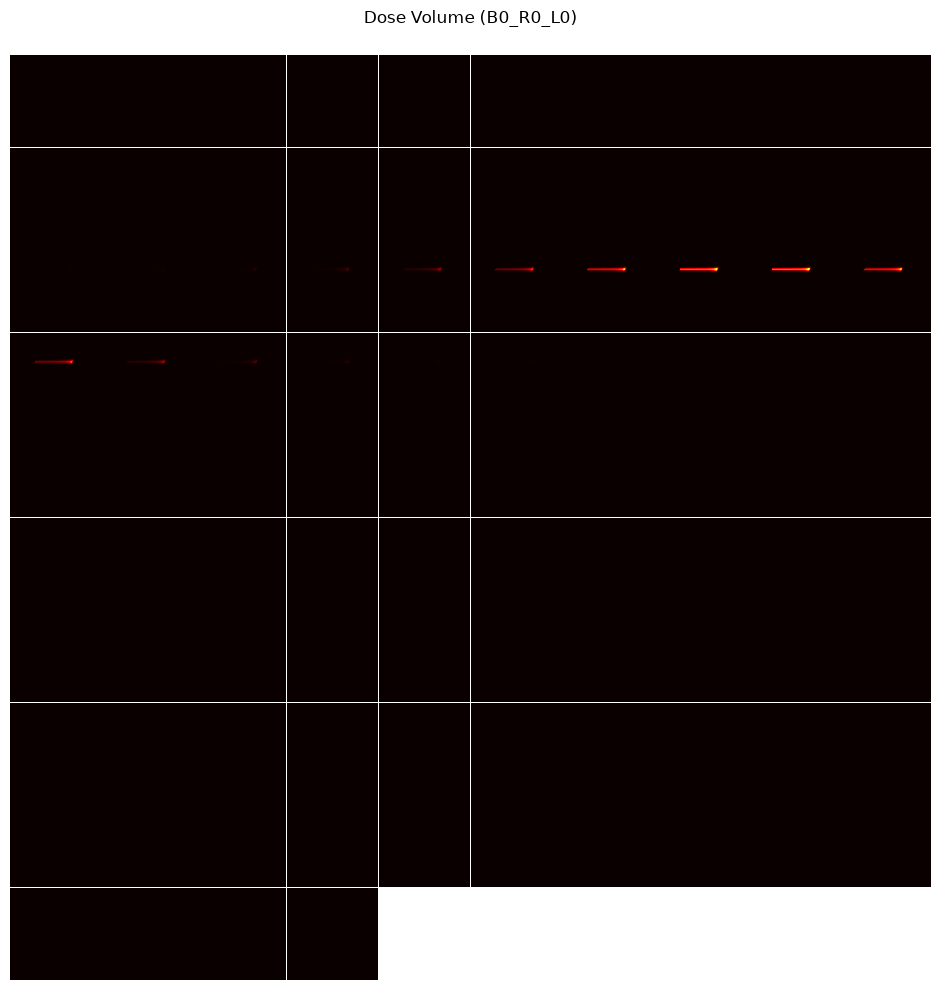

(<Figure size 1000x1000 with 1 Axes>,
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        ...,
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(4970, 4950), dtype=float32))

In [274]:
matshow3d(img, title=f"Dose Volume (B{B}_R{R}_L{L})", frame_dim=2, show=True, cmap='hot')

In [306]:
import torch
import numpy as np
import nibabel as nib
from monai.transforms import MapTransform

class ExtractSlabsAroundZ(MapTransform):
    def __init__(self, keys, source_key="ray_source", slice_radius=15, allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)
        self.source_key = source_key
        # 15 slices above + 15 slices below + 1 center slice = 31 slices total
        self.slice_radius = slice_radius

    def __call__(self, data):
        d = dict(data)
        
        # 1. Extract the physical point (X, Y, Z)
        physical_point = np.array(d[self.source_key][:3])
        
        for key in self.key_iterator(d):
            img = d[key]
            
            # 2. Get the affine matrix from this specific image
            affine = img.affine.cpu().numpy()
            
            # 3. Invert the affine to create a "Physical to Voxel" mapping
            inv_affine = np.linalg.inv(affine)
            
            # 4. Apply the inverted affine to your physical point
            voxel_coords = nib.affines.apply_affine(inv_affine, physical_point)
            
            # 5. Extract the Z index (the 3rd element)
            z_index = int(np.round(voxel_coords)[2])
            
            # 6. Calculate theoretical Z boundaries (can exceed image shape)
            # We add +1 to z_end because Python slicing is exclusive at the end
            z_start = z_index - self.slice_radius
            z_end = z_index + self.slice_radius + 1 
            
            # 7. Clamp bounds for safe numpy slicing
            z_min = max(0, z_start)
            z_max = min(img.shape[3], z_end)
            
            # 8. Crop the slab (Assuming shape is [Channel, X, Y, Z])
            # Notice we keep all of X and Y intact!
            cropped_img = img[:, :, :, z_min:z_max]
            
            # 9. Calculate exactly where Z-padding belongs if we hit a boundary
            pad_z_left = max(0, -z_start)
            pad_z_right = max(0, z_end - img.shape[3])
            
            # 10. Apply PyTorch Pad (F.pad goes from the last dim backwards)
            # We pass 0s for Y and X so ONLY the Z axis gets padded.
            if pad_z_left > 0 or pad_z_right > 0:
                cropped_img = torch.nn.functional.pad(
                    torch.as_tensor(cropped_img), 
                    (pad_z_left, pad_z_right, 0, 0, 0, 0), # (Z_left, Z_right, Y_left, Y_right, X_left, X_right)
                    mode='constant', value=0
                )
                
            d[key] = cropped_img
            
        return d

In [307]:
from monai.transforms import Lambdad
from monai.transforms import SelectItemsd
def scale_dose_by_1000(x):
    return x * 1000.0
from monai.transforms import MapTransform, ResizeWithPadOrCropd , EnsureTyped,Compose, LoadImaged, EnsureChannelFirstd, Spacingd, CenterSpatialCropd
from monai.transforms import ScaleIntensityRanged


In [308]:
import os
os.chdir("/users/ffbence/dose")

In [365]:
config_name = "default_config"
cfg = OmegaConf.load(f"configs/{config_name}.yaml")
data_cfg = cfg['data']
hw_cfg = OmegaConf.load(f"configs/hw_config.yaml")

train_list = json.load(open(data_cfg['train_list'], "r"))
val_list = json.load(open(data_cfg['val_list'], "r"))


In [ ]:

train_transforms = Compose([
LoadImaged(keys=["ct", "gt_dose"]),
EnsureChannelFirstd(keys=["ct", "gt_dose"]),
Lambdad(keys=["gt_dose"], func=scale_dose_by_1000),
ScaleIntensityRanged(keys=['ct'],a_min=data_cfg['ct_min'], a_max=data_cfg['ct_max'], b_min=0.0, b_max=1.0, clip=True),
ExtractSlabsAroundZ(keys=["ct", "gt_dose"], source_key="ray_source", slice_radius=15),
Spacingd(keys=["ct", "gt_dose"], pixdim=data_cfg['pixdim'], mode='nearest'), # pixdim = [4.0, 4.0, 3.0]
ResizeWithPadOrCropd(keys=["ct", "gt_dose"], spatial_size=data_cfg['roi_size']), #roi_size = [128, 128, 32] 
EnsureTyped(keys=["ct", "gt_dose", "condition"],track_meta=False,dtype=torch.float32),
SelectItemsd(keys=["ct", "gt_dose", "condition"])
])

In [367]:
torch.max(data['gt_dose'][:,:,:,15]), torch.max(data['gt_dose'][:,:,:,16]), torch.max(data['gt_dose'][:,:,:,17]), torch.max(data['gt_dose'][:,:,:,14]), torch.max(data['gt_dose'][:,:,:,13]),

(tensor(1.6303),
 tensor(1.4503),
 tensor(1.2082),
 tensor(1.2884),
 tensor(0.8481))

tensor(1.4594) tensor(1.3297) tensor(0.9783) tensor(1.2657) tensor(0.9111)


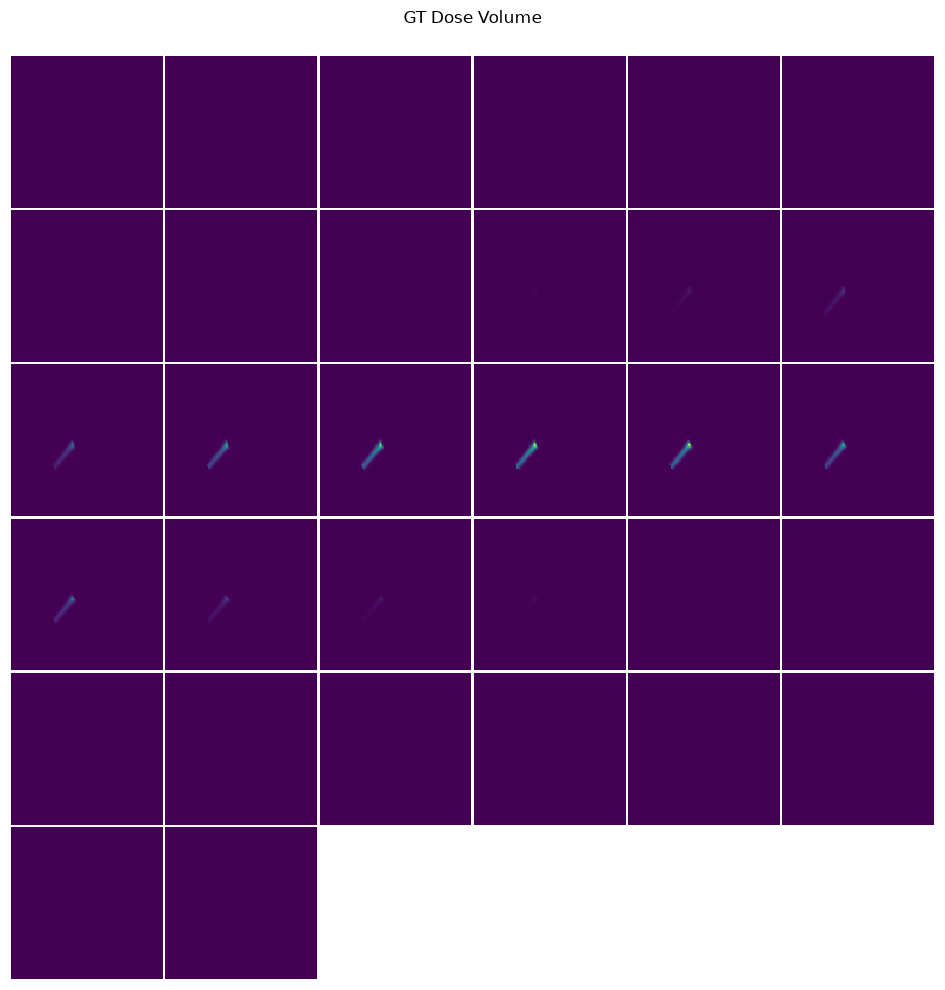

(<Figure size 1000x1000 with 1 Axes>,
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        ...,
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(780, 780), dtype=float32))

In [374]:
sample_dict = train_list[174]
data = train_transforms(sample_dict)
data['gt_dose'].shape
print(torch.max(data['gt_dose'][:,:,:,15]), torch.max(data['gt_dose'][:,:,:,16]), torch.max(data['gt_dose'][:,:,:,17]), torch.max(data['gt_dose'][:,:,:,14]), torch.max(data['gt_dose'][:,:,:,13]),)
matshow3d(data['gt_dose'], title="GT Dose Volume", frame_dim=-1, show=True)

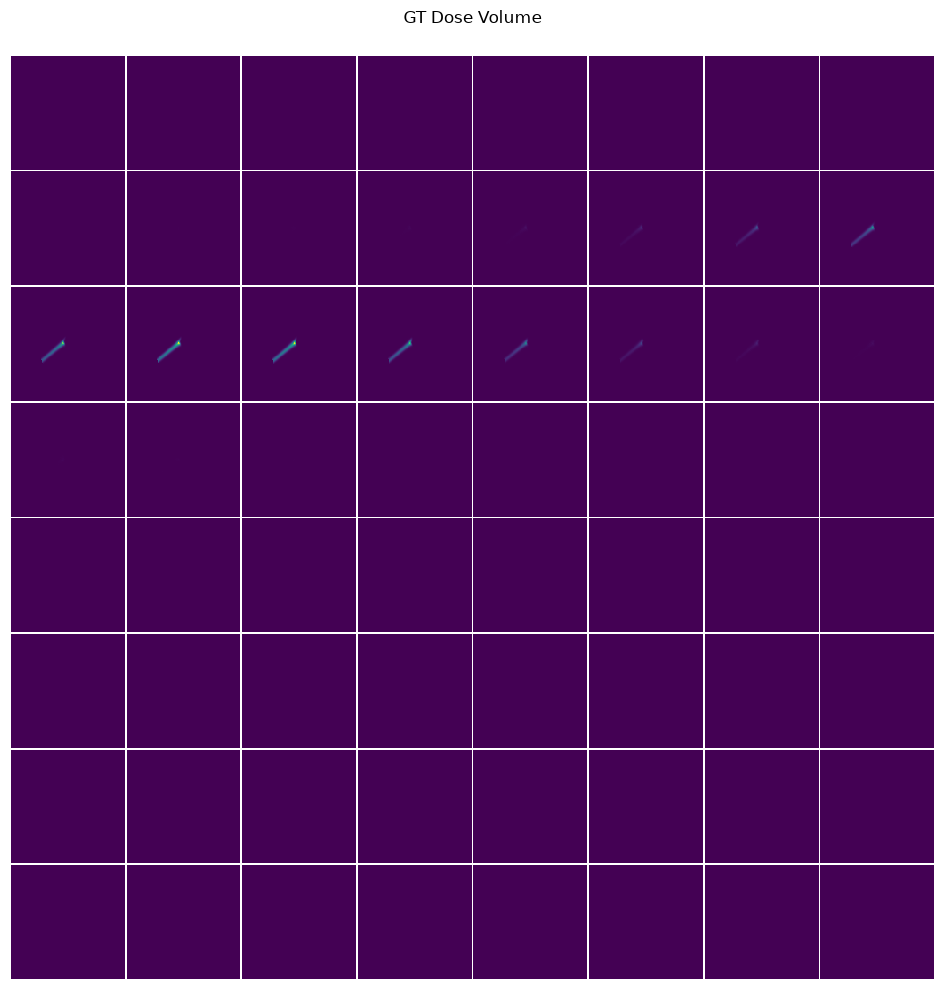

(<Figure size 1000x1000 with 1 Axes>,
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        ...,
        [nan,  0.,  0., ...,  0.,  0., nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(1040, 1040), dtype=float32))

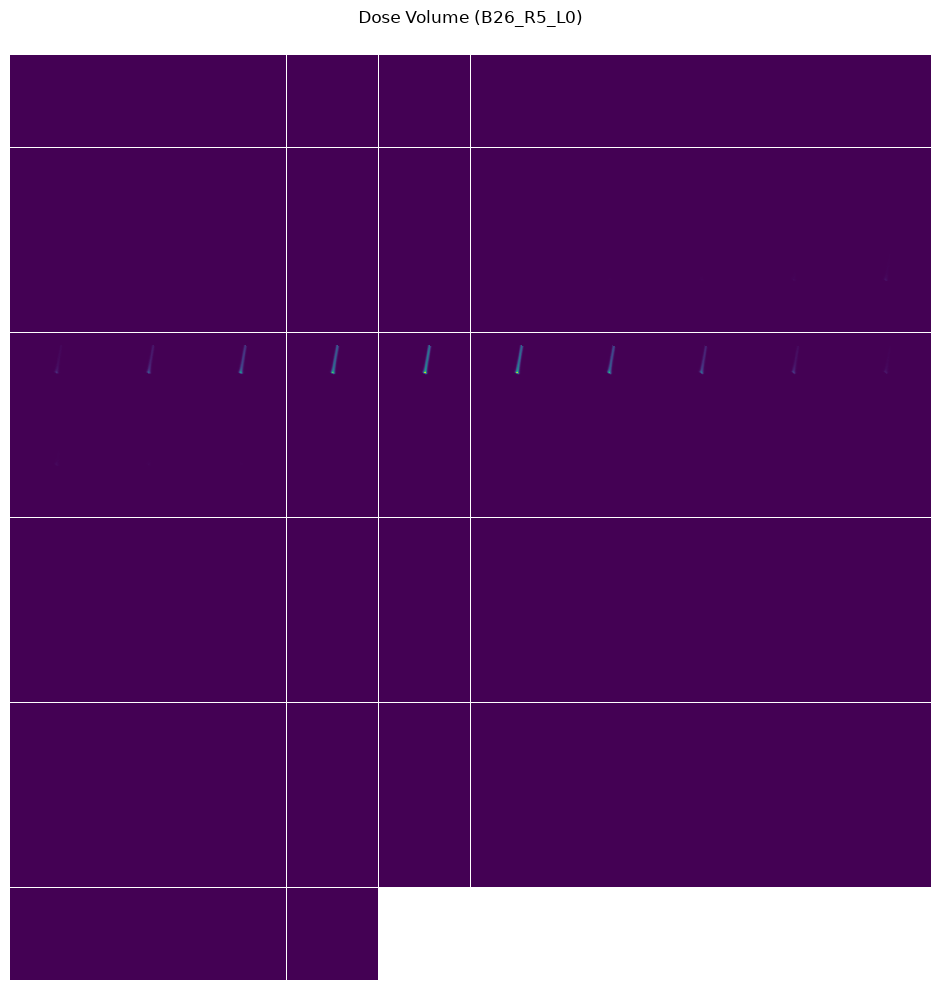

(<Figure size 1000x1000 with 1 Axes>,
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        ...,
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(4970, 4950), dtype=float32))

In [93]:
matshow3d(img, title=f"Dose Volume (B{B}_R{R}_L{L})", frame_dim=2, show=True)

In [25]:
ray_source = (-30,-40,-33) # x,y,z
ray_target  = (-30,10,-33) # x,y,z

In [26]:
# create 128x128x32 volume with the segment between ray_source and ray_target set to 1
nx, ny, nz = 128, 128, 32
vol = np.zeros((nx, ny, nz), dtype=np.uint8)

p0 = np.array(ray_source, dtype=float)
p1 = np.array(ray_target, dtype=float)

# Map ray_source to the center voxel so its z coordinate falls on the middle slice
center = np.array([nx // 2, ny // 2, nz // 2], dtype=float)

# sample along the segment and rasterize into voxel indices
num_pts = max(int(np.ceil(np.linalg.norm(p1 - p0) * 4)), 10)
pts = np.linspace(p0, p1, num_pts)
vox_idxs = np.round(center + (pts - p0)).astype(int)

for x, y, z in vox_idxs:
    if 0 <= x < nx and 0 <= y < ny and 0 <= z < nz:
        vol[x, y, z] = 1

line_volume128 = vol  # result: shape (128,128,32), 1 inside segment, 0 elsewhere
line_volume128.sum()

np.uint64(51)

In [27]:
import matplotlib.pyplot as plt

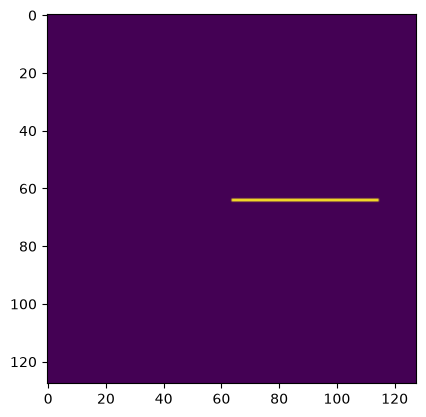

In [28]:
plt.imshow(line_volume128[:,:,16])

In [14]:
line_volume128.shape

(128, 128, 32)

# Injector testing


In [7]:
from monai.transforms import Lambdad, MapTransform
import os
os.chdir("/users/ffbence/dose")

In [8]:
class ExtractSlabsAroundZ(MapTransform):
    def __init__(self, keys, source_key="ray_source", slice_radius=15, allow_missing_keys=False):
        super().__init__(keys, allow_missing_keys)
        self.source_key = source_key
        # 15 slices above + 15 slices below + 1 center slice = 31 slices total
        self.slice_radius = slice_radius

    def __call__(self, data):
        d = dict(data)
        
        # 1. Extract the physical point (X, Y, Z)
        physical_point = np.array(d[self.source_key][:3])
        
        for key in self.key_iterator(d):
            img = d[key]
            
            # 2. Get the affine matrix from this specific image
            affine = img.affine.cpu().numpy()
            
            # 3. Invert the affine to create a "Physical to Voxel" mapping
            inv_affine = np.linalg.inv(affine)
            
            # 4. Apply the inverted affine to your physical point
            voxel_coords = nib.affines.apply_affine(inv_affine, physical_point)
            
            # 5. Extract the Z index (the 3rd element)
            z_index = int(np.round(voxel_coords)[2])
            
            # 6. Calculate theoretical Z boundaries (can exceed image shape)
            # We add +1 to z_end because Python slicing is exclusive at the end
            z_start = z_index - self.slice_radius
            z_end = z_index + self.slice_radius + 1 
            
            # 7. Clamp bounds for safe numpy slicing
            z_min = max(0, z_start)
            z_max = min(img.shape[3], z_end)
            
            # 8. Crop the slab (Assuming shape is [Channel, X, Y, Z])
            # Notice we keep all of X and Y intact!
            cropped_img = img[:, :, :, z_min:z_max+1]
            
            # 9. Calculate exactly where Z-padding belongs if we hit a boundary
            pad_z_left = max(0, -z_start)
            pad_z_right = max(0, z_end - img.shape[3])
            
            # 10. Apply PyTorch Pad (F.pad goes from the last dim backwards)
            # We pass 0s for Y and X so ONLY the Z axis gets padded.
            if pad_z_left > 0 or pad_z_right > 0:
                cropped_img = torch.nn.functional.pad(
                    torch.as_tensor(cropped_img), 
                    (pad_z_left, pad_z_right, 0, 0, 0, 0), # (Z_left, Z_right, Y_left, Y_right, X_left, X_right)
                    mode='constant', value=0
                )
                
            d[key] = cropped_img
            
        return d

In [9]:
import json
from monai.transforms import Compose, LoadImaged, EnsureTyped, EnsureChannelFirstd, Spacingd, ResizeWithPadOrCropd, Lambdad, ScaleIntensityRanged, CenterSpatialCropd

In [23]:
import numpy as np
import torch
import nibabel as nib
from monai.transforms import MapTransform

class InjectGaussianBeamPriord(MapTransform):
    def __init__(self, keys, source_key="ray_source", target_key="ray_target", ref_key="ct", sigma=4.0, flip_lps_to_ras=True):
        super().__init__(keys)
        self.source_key = source_key
        self.target_key = target_key
        self.ref_key = ref_key
        self.sigma = sigma 
        self.flip_lps_to_ras = flip_lps_to_ras

    def __call__(self, data):
        d = dict(data)
        
        # 1. Extract Physical Coordinates (Make a copy so we don't permanently alter the original data)
        phys_source = np.array(d[self.source_key][:3], copy=True)
        phys_target = np.array(d[self.target_key][:3], copy=True)
        
        # 2. Coordinate System Alignment (LPS -> RAS)
        if self.flip_lps_to_ras:
            # Negating X and Y physically mirrors the points to match MONAI's default RAS space
            phys_source[0] = -phys_source[0]
            phys_source[1] = -phys_source[1]
            phys_target[0] = -phys_target[0]
            phys_target[1] = -phys_target[1]
        
        # 3. Apply the Affine Mapping
        ct_tensor = d[self.ref_key]
        affine = ct_tensor.affine.cpu().numpy()
        inv_affine = np.linalg.inv(affine)
        
        vox_source = nib.affines.apply_affine(inv_affine, phys_source)
        vox_target = nib.affines.apply_affine(inv_affine, phys_target)
        
        # --- MODIFICATION: Lock the Z-axis to the 16th slice (index 15) ---
        # This forces the origin and target to sit perfectly in the center of the 32-slice depth.
        vox_source[2] = 15.0
        vox_target[2] = 15.0
        
        device = ct_tensor.device
        A = torch.tensor(vox_source, dtype=torch.float32, device=device) # Source
        B = torch.tensor(vox_target, dtype=torch.float32, device=device) # Target
        
        # 4. Generate 3D Grid
        _, X, Y, Z = ct_tensor.shape
        x_grid, y_grid, z_grid = torch.meshgrid(
            torch.arange(X, device=device), 
            torch.arange(Y, device=device), 
            torch.arange(Z, device=device), 
            indexing='ij'
        )
        P = torch.stack([x_grid, y_grid, z_grid], dim=-1).float() 
        
        # 5. Distance and Vector Math
        AB = B - A
        AP = P - A
        
        dot_AP_AB = torch.sum(AP * AB, dim=-1)
        dot_AB_AB = torch.sum(AB * AB, dim=-1)
        
        # t is the position along the line segment. 
        # t=0 is Source, t=1 is Target.
        t_raw = dot_AP_AB / (dot_AB_AB + 1e-8)
        
        # Clamp maximum at 1.0 to find the closest point strictly up to the target
        t_clamped = torch.clamp(t_raw, max=1.0)
        
        C = A + t_clamped.unsqueeze(-1) * AB
        dist_sq = torch.sum((P - C)**2, dim=-1)
        
        # 6. Apply Gaussian Spread
        gaussian_prior = torch.exp(-dist_sq / (2 * self.sigma**2))
        
        # 7. Bragg Peak Cutoff
        # Hard mask any voxel that is physically past the target point (t > 1.0)
        gaussian_prior[t_raw > 1.0] = 0.0
        
        d["geometric_prior"] = gaussian_prior.unsqueeze(0)
        
        return d

In [24]:
from omegaconf import OmegaConf
import json
config_name = "default_config"
cfg = OmegaConf.load(f"configs/{config_name}.yaml")
data_cfg = cfg['data']
hw_cfg = OmegaConf.load(f"configs/hw_config.yaml")

train_list = json.load(open(data_cfg['train_list'], "r"))
val_list = json.load(open(data_cfg['val_list'], "r"))

In [25]:
import matplotlib.pyplot as plt

In [36]:
from monai.visualize import matshow3d

{'ct': 'data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/1ABB161/image/ct.mha', 'gt_dose': 'data/LMUK-RADONC-PHYS-RES__DoseRAD2026/proton/training/1ABB161/dose/Dose_B4_R0_L0.mha', 'ray_source': [638.39, -786.21, -43.85], 'ray_target': [-0.8114968818206307, -17.17069906405959, -43.85], 'condition': [-0.6392014968818206, 0.7690393009359404, 133.3749]}


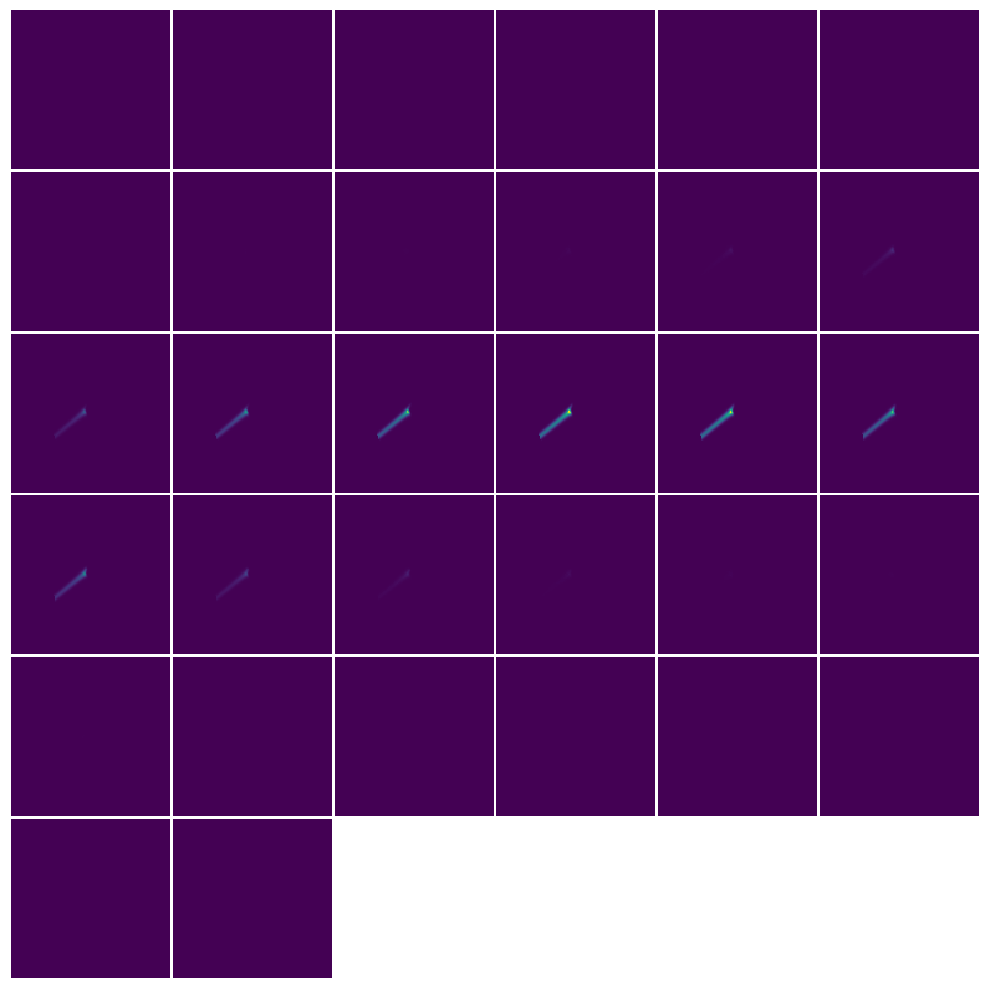

In [62]:
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, Spacingd, ResizeWithPadOrCropd, EnsureTyped
transforms = Compose([
    LoadImaged(keys=["ct","gt_dose"]),
    EnsureChannelFirstd(keys=["ct", "gt_dose"]),
    ExtractSlabsAroundZ(keys=["ct", "gt_dose"], source_key="ray_source", slice_radius=15),
    Spacingd(keys=["ct", "gt_dose"], pixdim=data_cfg['pixdim'], mode='trilinear'), # pixdim = [4.0, 4.0, 3.0]
    ResizeWithPadOrCropd(keys=["ct", "gt_dose"], spatial_size=data_cfg['roi_size']), #roi_size = [128, 128, 32] 
    InjectGaussianBeamPriord(keys =['ct'],source_key="ray_source", target_key="ray_target", ref_key="ct", sigma=4.0, flip_lps_to_ras = True),
    EnsureTyped(keys=["ct", "gt_dose", "condition"],track_meta=False,dtype=torch.float32),
    EnsureTyped(keys = ['ray_source',"ray_target"],dtype=torch.float32)

])

jsons = json.load(open('data/train.json', "r"))
sample_dict = jsons[120]
print(sample_dict)
data = transforms(sample_dict)
_= matshow3d(data["gt_dose"][0],frame_dim = -1,)

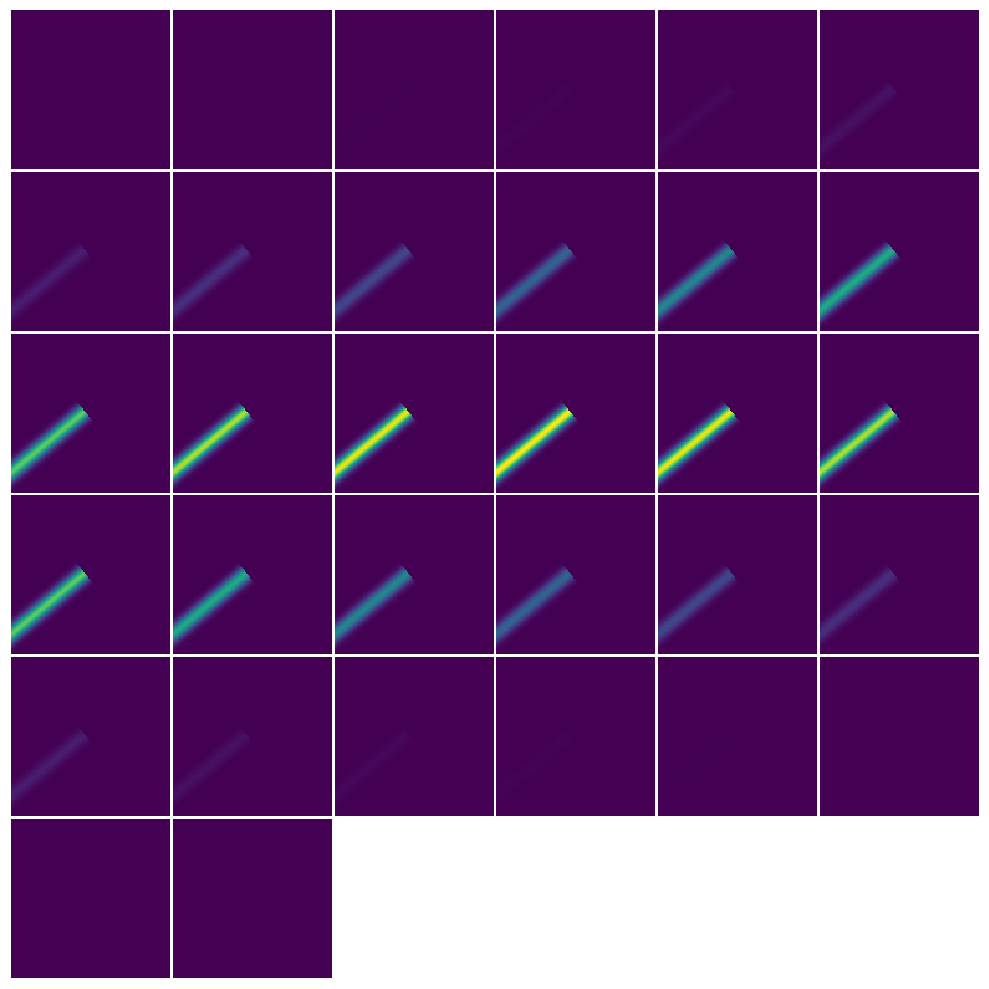

In [63]:
_ = matshow3d(data["geometric_prior"][0],frame_dim = -1,)

# Data Loader safety check

In [8]:
from scripts.data_loader import get_loaders
from monai.visualize import matshow3d

In [3]:
train_loader, val_loader = get_loaders(hw = "atlasz")

In [4]:
batch = next(iter(val_loader))

In [7]:
batch['geometric_prior'].shape

torch.Size([256, 1, 128, 128, 32])

(<Figure size 1000x1000 with 1 Axes>,
 array([[          nan,           nan,           nan, ...,           nan,
                   nan,           nan],
        [          nan, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00,           nan],
        [          nan, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
         0.0000000e+00,           nan],
        ...,
        [          nan, 1.8586051e-32, 1.8586051e-32, ...,           nan,
                   nan,           nan],
        [          nan, 8.7732975e-34, 8.7732975e-34, ...,           nan,
                   nan,           nan],
        [          nan,           nan,           nan, ...,           nan,
                   nan,           nan]], shape=(780, 780), dtype=float32))

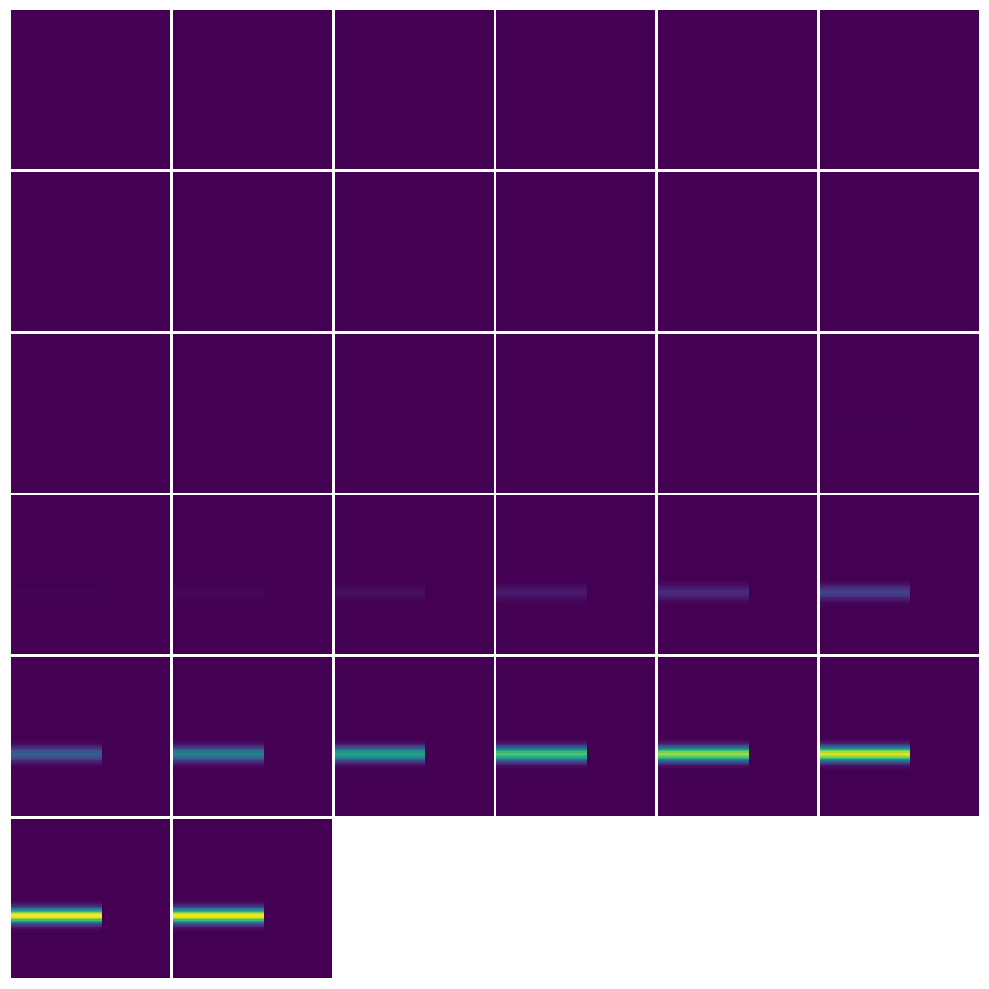

In [9]:
matshow3d(batch['geometric_prior'][0],frame_dim = -1 )

(<Figure size 1000x1000 with 1 Axes>,
 array([[nan, nan, nan, ..., nan, nan, nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        [nan,  0.,  0., ...,  0.,  0., nan],
        ...,
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan,  0.,  0., ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],
       shape=(780, 780), dtype=float32))

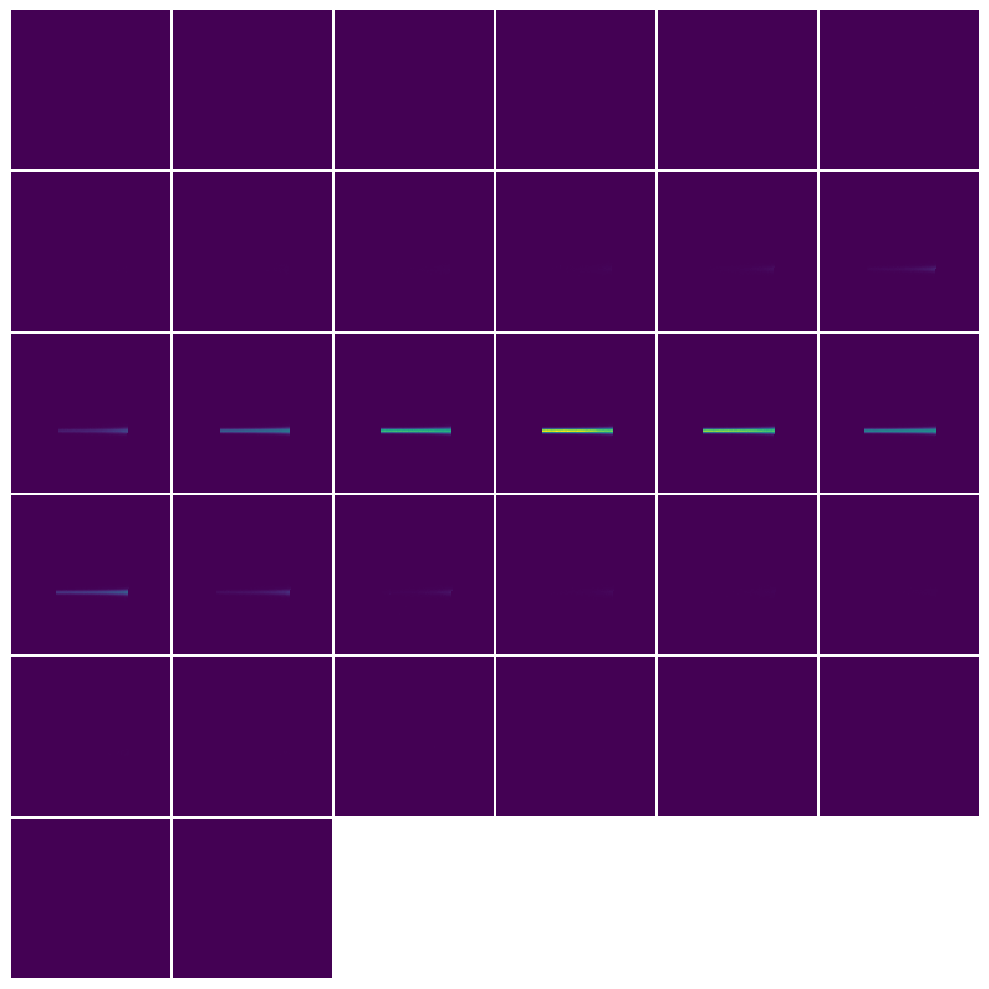

In [10]:
matshow3d(batch['gt_dose'][0],frame_dim = -1 )